In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('separated_all_100.csv')
df['datetime_start'] = pd.to_datetime(df['datetime_start'])
survey = pd.read_csv('survey_all_100.csv')

# ── 1. ID linkage ──────────────────────────────────────────────
ts_ids = set(df['ID'].unique())
survey_ids = set(survey['ID'].unique())
print(f"Unique IDs in time series: {df['ID'].nunique()}")
print(f"IDs in survey but not time series: {survey_ids - ts_ids}")
print(f"IDs in time series but not survey: {ts_ids - survey_ids}")

# ── 2. Date range ──────────────────────────────────────────────
print(f"\nStart: {df['datetime_start'].min()}")
print(f"End:   {df['datetime_start'].max()}")
print(f"Total days: {(df['datetime_start'].max() - df['datetime_start'].min()).days}")

# ── 3. kWh quality ────────────────────────────────────────────
print(f"\nNegatives:       {(df['kWh'] < 0).sum()}")
print(f"Zeros:           {(df['kWh'] == 0).sum()} ({100*(df['kWh']==0).sum()/len(df):.2f}%)")
print(f"Max kWh:         {df['kWh'].max()}")
print(f"99th percentile: {df['kWh'].quantile(0.99):.3f}")
print(f"Mean:            {df['kWh'].mean():.4f}")

# ── 4. Readings per household ( per-household expected) ─
household_summary = (
    df.groupby('ID')
      .agg(
          start=('datetime_start', 'min'),
          end=('datetime_start', 'max'),
          readings=('kWh', 'size')
      )
)

household_summary['days'] = (
    household_summary['end'] - household_summary['start']
).dt.days + 1

household_summary['expected'] = household_summary['days'] * 48
household_summary['missing'] = (
    household_summary['expected'] - household_summary['readings']
)

print(household_summary[['readings', 'expected', 'missing']].describe())
print("\nHouseholds with missing readings:")
print(household_summary[household_summary['missing'] > 0][['readings', 'expected', 'missing']])

Unique IDs in time series: 100
IDs in survey but not time series: set()
IDs in time series but not survey: set()

Start: 2009-07-14 00:00:00
End:   2010-12-31 23:30:00
Total days: 535

Negatives:       0
Zeros:           9217 (0.36%)
Max kWh:         12.33
99th percentile: 3.463
Mean:            0.5239
       readings  expected  missing
count     100.0     100.0    100.0
mean    25726.0   25728.0      2.0
std         0.0       0.0      0.0
min     25726.0   25728.0      2.0
25%     25726.0   25728.0      2.0
50%     25726.0   25728.0      2.0
75%     25726.0   25728.0      2.0
max     25726.0   25728.0      2.0

Households with missing readings:
      readings  expected  missing
ID                               
1002     25726     25728        2
1003     25726     25728        2
1004     25726     25728        2
1005     25726     25728        2
1013     25726     25728        2
...        ...       ...      ...
1222     25726     25728        2
1224     25726     25728        2
1225  

##### Every household is missing exactly 2 readings. This is almost certainly the DST (daylight saving time) clock change, when clocks go forward one hour in spring, two half-hour slots disappear. Since it's consistent across all 100 households, it's a data collection artefact, not a quality issue.

In [2]:
# Check which timestamps are missing for one household
hh = df[df['ID'] == 1002].set_index('datetime_start')
full_index = pd.date_range(
    start=hh.index.min(),
    end=hh.index.max(),
    freq='30min'
)
missing_timestamps = full_index.difference(hh.index)
print(missing_timestamps)

DatetimeIndex(['2010-03-28 00:30:00', '2010-03-28 01:00:00'], dtype='datetime64[ns]', freq='30min')


#### All 100 households had near-complete half-hourly electricity consumption records spanning 14 July 2009 to 31 December 2010. Each household contained 25,726 observations, two fewer than the expected 25,728 half-hour intervals. Investigation showed that the missing observations corresponded to the daylight saving time (DST) transition on 28 March 2010, when two half-hour periods were omitted across all households. As this reflects a calendar effect rather than data loss, no imputation was performed.


In [3]:
# ── Survey missingness ─────────────────────────────────────────
missing = survey.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(survey) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(missing_df.to_string())

                                                                                                                                                                                                                                                                 missing    pct
Question.5415..By.what.amount.                                                                                                                                                                                                                                       100  100.0
Question.4551..What.rating.did.your.house.achieve.                                                                                                                                                                                                                    99   99.0
Question.474..Have.any.of.the.following.ever.applied.to.you...None.of.these                                                                                                             

In [4]:
# Check if the 18 missing Q420 households are the same ones
q420_missing = survey[survey['Question.420..How.many.people.over.15.years.of.age.live.in.your.home.'].isnull()]['ID']
q430_missing = survey[survey['Question.430..And.how.many.of.these.are.typically.in.the.house.during.the.day..for.example.for.5.6.hours.during.the.day.'].isnull()]['ID']

print("Same households missing both?", set(q420_missing) == set(q430_missing))
print("Count:", len(q420_missing))

Same households missing both? True
Count: 18


In [5]:
# Q410: 1=live alone, 2=all over 15, 3=adults and children
q410_col = [c for c in survey.columns if 'Question.410' in c][0]
q420_col = [c for c in survey.columns if 'Question.420' in c][0]

print(survey[survey['ID'].isin(q420_missing)][q410_col].value_counts())

Question.410..What.best.describes.the.people.you.live.with..READ.OUT
1    18
Name: count, dtype: int64


In [6]:
q420_col = [c for c in survey.columns if 'Question.420..' in c][0]
q430_col = [c for c in survey.columns if 'Question.430..' in c][0]

# Q420: people over 15 → must be 1 (they live alone)
survey.loc[survey['ID'].isin(q420_missing), q420_col] = 1

# Q430: people typically home during day → use median of other single-person households
single_median = survey.loc[
    survey[q420_col] == 1, q430_col
].median()

survey.loc[survey['ID'].isin(q420_missing), q430_col] = single_median

print(f"Q420 nulls remaining: {survey[q420_col].isnull().sum()}")
print(f"Q430 imputed with median: {single_median}")
print(f"Q430 nulls remaining: {survey[q430_col].isnull().sum()}")

Q420 nulls remaining: 0
Q430 imputed with median: 1.0
Q430 nulls remaining: 0


#####  Q420 (number of adults in the household) and Q430 (number of adults typically at home during the day) were missing for 18 households due to survey routing. All affected respondents had previously indicated that they lived alone (Q410 = 1). Therefore, household size (Q420) was logically derived as one adult rather than treated as missing. Daytime occupancy (Q430) was imputed using the median value among other confirmed single-person households. Following these corrections, both variables were complete.

In [7]:
# Aggregate to daily total kWh per household
df['datetime_start'] = pd.to_datetime(df['datetime_start'])
df['date'] = df['datetime_start'].dt.date

daily = (
    df.groupby(['ID', 'date'])['kWh']
      .sum()
      .reset_index()
)
daily['date'] = pd.to_datetime(daily['date'])
daily['month'] = daily['date'].dt.month
daily['dayofweek'] = daily['date'].dt.dayofweek  # 0=Monday
daily['season'] = daily['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

print(daily.shape)
print(daily.describe())

(53600, 6)
                ID                           date           kWh         month  \
count  53600.00000                          53600  53600.000000  53600.000000   
mean    1110.50000  2010-04-07 11:59:59.999999744     25.144470      7.533582   
min     1002.00000            2009-07-14 00:00:00      0.062000      1.000000   
25%     1057.75000            2009-11-24 18:00:00     13.570000      5.000000   
50%     1108.50000            2010-04-07 12:00:00     21.512500      8.000000   
75%     1164.25000            2010-08-19 06:00:00     33.849750     10.000000   
max     1229.00000            2010-12-31 00:00:00    223.510000     12.000000   
std       64.39633                            NaN     16.577964      3.332760   

          dayofweek  
count  53600.000000  
mean       2.996269  
min        0.000000  
25%        1.000000  
50%        3.000000  
75%        5.000000  
max        6.000000  
std        1.995345  


#### Max daily kWh of 223.51 is very high, that's over 9x the 75th percentile of 33.8. Worth checking if it's a genuine outlier or data error

In [8]:
# Investigate extreme daily values
print(daily.nlargest(10, 'kWh')[['ID', 'date', 'kWh']])

# Distribution of per-household mean daily consumption
hh_mean = daily.groupby('ID')['kWh'].mean()
print("\nPer-household mean daily kWh:")
print(hh_mean.describe())
print(f"\nHighest consuming household: {hh_mean.idxmax()}, {hh_mean.max():.1f} kWh/day")
print(f"Lowest consuming household:  {hh_mean.idxmin()}, {hh_mean.min():.1f} kWh/day")

         ID       date      kWh
31617  1126 2010-12-25  223.510
31616  1126 2010-12-24  211.475
31615  1126 2010-12-23  206.202
49452  1203 2009-12-01  165.911
51984  1224 2010-12-24  159.439
51985  1224 2010-12-25  154.346
53057  1227 2010-12-25  148.028
53056  1227 2010-12-24  147.753
52735  1227 2010-02-06  139.878
52687  1227 2009-12-20  138.940

Per-household mean daily kWh:
count    100.000000
mean      25.144470
std       13.335748
min        3.497151
25%       16.529117
50%       21.446851
75%       33.260365
max       78.523034
Name: kWh, dtype: float64

Highest consuming household: 1227, 78.5 kWh/day
Lowest consuming household:  1069, 3.5 kWh/day


##### The extreme values cluster around Christmas (Dec 23–25) and cold winter days — consistent with electric heating running at maximum during the coldest period of the year
##### Household 1227 averages 78.5 kWh/day — over 3× the median of 21.4 — almost certainly electric heating as primary heat source, worth cross-checking against Q470
#####  Household 1069 at 3.5 kWh/day is very low — possibly a rarely occupied home or minimal appliance use

In [9]:
# Check heating type for highest and lowest consuming households
q470_cols = [c for c in survey.columns if 'Question.470' in c]
print(survey[survey['ID'].isin([1227, 1069])][['ID'] + q470_cols])

      ID  \
33  1069   
98  1227   

    Question.470..Which.of.the.following.best.describes.how.you.heat.your..Electricity..electric.central.heating.storage.heating.  \
33                                                  0                                                                               
98                                                  0                                                                               

    Question.470..Which.of.the.following.best.describes.how.you.heat.your..Electricity..plug.in.heaters.  \
33                                                  0                                                      
98                                                  0                                                      

    Question.470..Which.of.the.following.best.describes.how.you.heat.your..Gas  \
33                                                  0                            
98                                                  0                     

##### Interesting — both households use oil heating, not electric. So Q470 doesn't explain the consumption difference between them. The heterogeneity must come from elsewhere.

In [10]:
q420_col = [c for c in survey.columns if 'Question.420..' in c][0]
q460_col = [c for c in survey.columns if 'Question.460.' in c][0]
q49002_cols = [c for c in survey.columns if 'Question.49002' in c]

print(survey[survey['ID'].isin([1227, 1069])][['ID', q420_col, q460_col] + q49002_cols])

      ID  \
33  1069   
98  1227   

    Question.420..How.many.people.over.15.years.of.age.live.in.your.home.  \
33                                                2.0                       
98                                                5.0                       

    Question.460..How.many.bedrooms.are.there.in.your.home  \
33                                                  3        
98                                                  5        

    Question.49002..Washing.machine  Question.49002..Tumble.dryer  \
33                                2                             2   
98                                2                             2   

    Question.49002..Dishwasher  Question.49002..Electric.shower..instant.  \
33                           1                                          1   
98                           2                                          2   

    Question.49002..Electric.shower..electric.pumped.from.hot.tank.  \
33                               

#### Substantial heterogeneity exists across households. The highest-consuming household (ID 1227; mean 78.5 kWh/day) is a large five-person, five-bedroom home with multiple high-draw appliances, whereas the lowest-consuming household (ID 1069; mean 3.5 kWh/day) has broadly similar heating characteristics and appliance ownership but substantially lower electricity demand. This suggests that occupancy, dwelling characteristics, and patterns of appliance use may be more important drivers of consumption than heating fuel type alone. Peak daily consumptions exceeding 200 kWh occurred during the Christmas period and winter months, indicating seasonal behavioural and heating effects rather than metering errors.


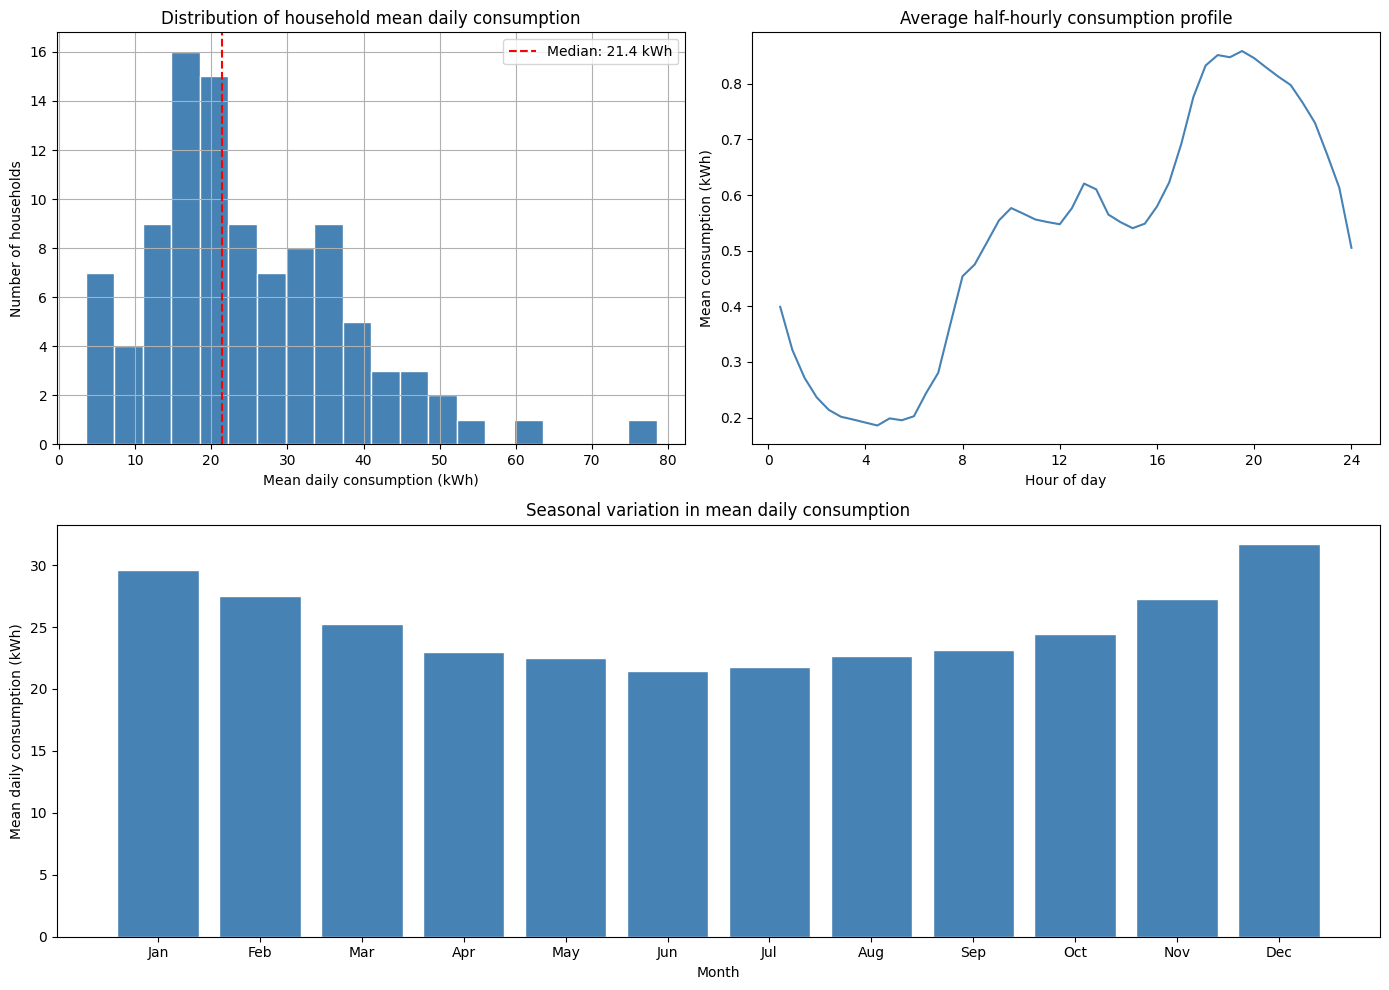

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# ── 1. Distribution of household mean daily consumption ────────
ax1 = fig.add_subplot(gs[0, 0])
hh_mean.hist(bins=20, ax=ax1, color='steelblue', edgecolor='white')
ax1.set_xlabel('Mean daily consumption (kWh)')
ax1.set_ylabel('Number of households')
ax1.set_title('Distribution of household mean daily consumption')
ax1.axvline(hh_mean.median(), color='red', linestyle='--', label=f'Median: {hh_mean.median():.1f} kWh')
ax1.legend()

# ── 2. Average half-hourly profile across all households ───────
ax2 = fig.add_subplot(gs[0, 1])
halfhour_profile = df.groupby('halfhour')['kWh'].mean()
ax2.plot(halfhour_profile.index / 2, halfhour_profile.values, color='steelblue')
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Mean consumption (kWh)')
ax2.set_title('Average half-hourly consumption profile')
ax2.set_xticks(range(0, 25, 4))

# ── 3. Mean daily consumption by month ────────────────────────
ax3 = fig.add_subplot(gs[1, :])
monthly = daily.groupby('month')['kWh'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax3.bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_labels)
ax3.set_xlabel('Month')
ax3.set_ylabel('Mean daily consumption (kWh)')
ax3.set_title('Seasonal variation in mean daily consumption')

plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

### Key insights

**Distribution (top left):** Right-skewed with median 21.4 kWh/day. Most households cluster between 10–35 kWh, but a long tail extends to 80 kWh, indicating substantial heterogeneity across households.

**Half-hourly profile (top right):** Classic residential double-peak pattern, with a morning peak around 08:00–09:00 and a stronger evening peak around 18:00–20:00. Overnight demand falls to a low baseload level. This is consistent with typical residential electricity consumption patterns.

**Seasonal variation (bottom):** Clear U-shaped seasonal pattern. Mean daily consumption is highest in December (31.5 kWh/day) and lowest during summer (21–22 kWh/day), representing roughly a 50% increase in winter demand.

These findings suggest that both temporal factors (time of day and season) and household-specific characteristics are likely to influence electricity demand and should therefore be incorporated into the forecasting analysis.

In [12]:
# ── Merge daily consumption with survey covariates ─────────────
# Shorten column names for usability
survey_clean = survey.copy()
survey_clean.columns = (
    survey_clean.columns
    .str.replace(r'Question\.\d+\.+', 'Q_', regex=True)
    .str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
    .str.strip('_')
)

# Select covariate columns (from our earlier selection)
covariate_cols_clean = [col for col in survey_clean.columns if any(q in col for q in [
    'Q_420', 'Q_430', 'Q_450', 'Q_460',
    'Q_470', 'Q_49001', 'Q_49002', 'Q_4704',
    'Q_4905', 'Q_4906'
])]

survey_subset = survey_clean[['ID'] + covariate_cols_clean]

# ── Build modelling dataset ────────────────────────────────────
model_df = daily.merge(survey_subset, on='ID', how='left')

# ── Temporal features ──────────────────────────────────────────
model_df['month']      = model_df['date'].dt.month
model_df['dayofweek']  = model_df['date'].dt.dayofweek
model_df['is_weekend'] = (model_df['dayofweek'] >= 5).astype(int)
model_df['season']     = model_df['month'].map({
    12:0, 1:0, 2:0,   # Winter
    3:1,  4:1, 5:1,   # Spring
    6:2,  7:2, 8:2,   # Summer
    9:3, 10:3, 11:3   # Autumn
})

print(model_df.shape)
print(model_df.isnull().sum()[model_df.isnull().sum() > 0])


(53600, 7)
Series([], dtype: int64)


In [13]:
print(survey_clean.columns.tolist()[:20])
print(f"\nTotal columns: {len(survey_clean.columns)}")
print(f"\nCovariate cols found: {len(covariate_cols_clean)}")

['Unnamed__0', 'ID', 'Q_PLEASE_RECORD_SEX_FROM_VOICE', 'Q_May_I_ask_what_age_you_were_on_your_last_birthday__INT__IF_NECCESSARY__PROMPT_WITH_AGE_BANDS', 'Q_What_is_the_employment_status_of_the_chief_income_earner_in_your_household__is_he_she', 'Q_SOCIAL_CLASS_Interviewer__Respondent_said_that_occupation_of_chief_income_earner_was______CLASS__Please_code', 'Q_Do_you_have_internet_access_in_your_home', 'Q_Do_you_have_broadband_in_your_home', 'Q_Do_you_use_the_internet_regularly_yourself', 'Q_Are_there_other_people_in_your_household_that_use_the_internet_regularly', 'Q_What_best_describes_the_people_you_live_with__READ_OUT', 'Q_How_many_people_over_15_years_of_age_live_in_your_home', 'Q_And_how_many_of_these_are_typically_in_the_house_during_the_day__for_example_for_5_6_hours_during_the_day', 'Q_How_many_people_under_15_years_of_age_live_in_your_home', 'Q_And_how_many_of_these_are_typically_in_the_house_during_the_day__for_exanmple_for_5_6_hours_during_the_day', 'Q_I_we_am_are_interested_

In [14]:
covariate_keywords = [
    'people_over_15',           # Q420 household size
    'typically_in_the_house',   # Q430 daytime occupancy
    'bedrooms',                 # Q460
    'describes_your_home',      # Q450 home type
    'heat_your',                # Q470 heating type
    'heat_water',               # Q4701 water heating
    'cook_in_your_home',        # Q4704 cooking method
    'Washing_machine',          # Q49001/Q49002 appliances
    'Tumble_dryer',
    'Dishwasher',
    'Electric_shower',
    'Electric_cooker',
    'Electric_heater',
    'Stand_alone_freezer',
    'Immersion',
    'water_pump',
    'energy_saving',            # Q4905 bulbs
    'double_glazed',            # Q4906 windows
]

covariate_cols_clean = [
    col for col in survey_clean.columns
    if any(kw.lower() in col.lower() for kw in covariate_keywords)
]

print(f"Covariate cols found: {len(covariate_cols_clean)}")
print(covariate_cols_clean)

Covariate cols found: 55
['Q_How_many_people_over_15_years_of_age_live_in_your_home', 'Q_And_how_many_of_these_are_typically_in_the_house_during_the_day__for_example_for_5_6_hours_during_the_day', 'Q_And_how_many_of_these_are_typically_in_the_house_during_the_day__for_exanmple_for_5_6_hours_during_the_day', 'Q_I_would_now_like_to_ask_some_questions_about_your_home___Which_best_describes_your_home', 'Q_How_many_bedrooms_are_there_in_your_home', 'Q_Which_of_the_following_best_describes_how_you_heat_your__Electricity__electric_central_heating_storage_heating', 'Q_Which_of_the_following_best_describes_how_you_heat_your__Electricity__plug_in_heaters', 'Q_Which_of_the_following_best_describes_how_you_heat_your__Gas', 'Q_Which_of_the_following_best_describes_how_you_heat_your__Oil', 'Q_Which_of_the_following_best_describes_how_you_heat_your__Solid_fuel', 'Q_Which_of_the_following_best_describes_how_you_heat_your__Renewable__e_g__solar', 'Q_Which_of_the_following_best_describes_how_you_heat_yo

In [15]:
# Drop binary flags (Q49001) - keep counts (Q49002) instead
# Drop usage frequency (INT_PROBE) - high missingness
# Drop Q4312 (children daytime - 69% missing)
# Drop immersion usage (Q4801) - conditional, high missing

exclude_keywords = [
    'INT_PROBE',
    'for_exanmple',        # Q4312 typo in original survey
    'use_your_immersion',  # Q4801
]

# Keep only Q49002 counts, not Q49001 binary flags
# Identify duplicate appliance cols
binary_flag_cols = [c for c in covariate_cols_clean 
                    if any(a in c for a in ['Washing_machine', 'Tumble_dryer', 
                    'Dishwasher', 'Electric_shower', 'Electric_cooker',
                    'Electric_heater', 'Stand_alone', 'water_pump', 'Immersion'])
                    and 'INT_PROBE' not in c]

print("Binary vs count cols - need to distinguish:")
for c in binary_flag_cols:
    print(f"  {c}")

Binary vs count cols - need to distinguish:
  Q_Washing_machine
  Q_Tumble_dryer
  Q_Dishwasher
  Q_Electric_shower__instant
  Q_Electric_shower__electric_pumped_from_hot_tank
  Q_Electric_cooker
  Q_Electric_heater__plug_in_convector_heaters
  Q_Stand_alone_freezer
  Q_A_water_pump_or_electric_well_pump_or_pressurised_water_system
  Q_Immersion
  Q_Washing_machine
  Q_Tumble_dryer
  Q_Dishwasher
  Q_Electric_shower__instant
  Q_Electric_shower__electric_pumped_from_hot_tank
  Q_Electric_cooker
  Q_Electric_heater__plug_in_convector_heaters
  Q_Stand_alone_freezer
  Q_A_water_pump_or_electric_well_pump_or_pressurised_water_system
  Q_Immersion


In [18]:
# Use original survey columns to distinguish Q49001 (binary) vs Q49002 (count)
q49001_cols = [c for c in survey.columns if 'Question.49001' in c]
q49002_cols = [c for c in survey.columns if 'Question.49002' in c]

print("Q49001 (binary flags):", len(q49001_cols))
print("Q49002 (counts):", len(q49002_cols))

# Build final covariate set from ORIGINAL survey columns, then rename cleanly
final_survey_cols = (
    [c for c in survey.columns if any(q in c for q in [
        'Question.420..',   # household size
        'Question.430..',   # daytime occupancy
        'Question.450..',   # home type
        'Question.460..',   # bedrooms
        'Question.470..',   # heating type (all sub-columns)
        'Question.4704.',   # cooking method
        'Question.4905.',   # energy saving bulbs
        'Question.4906.',   # double glazing
    ])]
    + q49002_cols          # appliance counts only
)

print(f"\nFinal covariate count: {len(final_survey_cols)}")
for c in final_survey_cols:
    print(f"  {c}")

Q49001 (binary flags): 10
Q49002 (counts): 10

Final covariate count: 24
  Question.420..How.many.people.over.15.years.of.age.live.in.your.home.
  Question.430..And.how.many.of.these.are.typically.in.the.house.during.the.day..for.example.for.5.6.hours.during.the.day.
  Question.450..I.would.now.like.to.ask.some.questions.about.your.home...Which.best.describes.your.home.
  Question.460..How.many.bedrooms.are.there.in.your.home
  Question.470..Which.of.the.following.best.describes.how.you.heat.your..Electricity..electric.central.heating.storage.heating.
  Question.470..Which.of.the.following.best.describes.how.you.heat.your..Electricity..plug.in.heaters.
  Question.470..Which.of.the.following.best.describes.how.you.heat.your..Gas
  Question.470..Which.of.the.following.best.describes.how.you.heat.your..Oil
  Question.470..Which.of.the.following.best.describes.how.you.heat.your..Solid.fuel
  Question.470..Which.of.the.following.best.describes.how.you.heat.your..Renewable..e.g..solar.
  Que

In [19]:
# Extract subset from original survey with correct columns
survey_subset = survey[['ID'] + final_survey_cols].copy()

# Rename to short, clean names
short_names = {
    'Question.420..How.many.people.over.15.years.of.age.live.in.your.home.': 'adults',
    'Question.430..And.how.many.of.these.are.typically.in.the.house.during.the.day..for.example.for.5.6.hours.during.the.day.': 'adults_home_day',
    'Question.450..I.would.now.like.to.ask.some.questions.about.your.home...Which.best.describes.your.home.': 'home_type',
    'Question.460..How.many.bedrooms.are.there.in.your.home': 'bedrooms',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Electricity..electric.central.heating.storage.heating.': 'heat_elec_central',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Electricity..plug.in.heaters.': 'heat_elec_plugin',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Gas': 'heat_gas',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Oil': 'heat_oil',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Solid.fuel': 'heat_solid',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Renewable..e.g..solar.': 'heat_renewable',
    'Question.470..Which.of.the.following.best.describes.how.you.heat.your..Other': 'heat_other',
    'Question.4704..Which.of.the.following.best.describes.how.you.cook.in.your.home': 'cooking_type',
    'Question.4905..And.now.considering.energy.reduction.in.your.home.please.indicate.the.approximate.proportion.of.light.bulbs.which.are.energy.saving..or.CFL....INT.READ.OUT': 'energy_bulbs',
    'Question.4906..Please.indicate.the.approximate.proportion.of.windows.in.your.home.which.are.double.glazed...INT.READ.OUT': 'double_glazing',
    'Question.49002..Washing.machine': 'n_washing_machine',
    'Question.49002..Tumble.dryer': 'n_tumble_dryer',
    'Question.49002..Dishwasher': 'n_dishwasher',
    'Question.49002..Electric.shower..instant.': 'n_shower_instant',
    'Question.49002..Electric.shower..electric.pumped.from.hot.tank.': 'n_shower_pumped',
    'Question.49002..Electric.cooker': 'n_electric_cooker',
    'Question.49002..Electric.heater..plug.in.convector.heaters.': 'n_electric_heater',
    'Question.49002..Stand.alone.freezer': 'n_freezer',
    'Question.49002..A.water.pump.or.electric.well.pump.or.pressurised.water.system': 'n_water_pump',
    'Question.49002..Immersion': 'n_immersion',
}

survey_subset = survey_subset.rename(columns=short_names)

# Merge with daily consumption
model_df = daily.merge(survey_subset, on='ID', how='left')

# Add temporal features
model_df['month']      = model_df['date'].dt.month
model_df['dayofweek']  = model_df['date'].dt.dayofweek
model_df['is_weekend'] = (model_df['dayofweek'] >= 5).astype(int)
model_df['season']     = model_df['month'].map({
    12:0, 1:0, 2:0,
    3:1,  4:1, 5:1,
    6:2,  7:2, 8:2,
    9:3, 10:3, 11:3
})

print(model_df.shape)
print(model_df.isnull().sum()[model_df.isnull().sum() > 0])

(53600, 31)
Series([], dtype: int64)


In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ── Chronological train/test split ────────────────────────────
# Use last 3 months (Oct–Dec 2010) as test set
split_date = pd.Timestamp('2010-10-01')

train = model_df[model_df['date'] < split_date]
test  = model_df[model_df['date'] >= split_date]

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()} ({len(train):,} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()} ({len(test):,} rows)")

# ── Define feature sets ────────────────────────────────────────
temporal_features = ['month', 'dayofweek', 'is_weekend', 'season']

survey_features = [
    'adults', 'adults_home_day', 'home_type', 'bedrooms',
    'heat_elec_central', 'heat_elec_plugin', 'heat_gas',
    'heat_oil', 'heat_solid', 'heat_renewable', 'heat_other',
    'cooking_type', 'energy_bulbs', 'double_glazing',
    'n_washing_machine', 'n_tumble_dryer', 'n_dishwasher',
    'n_shower_instant', 'n_shower_pumped', 'n_electric_cooker',
    'n_electric_heater', 'n_freezer', 'n_water_pump', 'n_immersion'
]

target = 'kWh'

X_train_A = train[temporal_features]
X_test_A  = test[temporal_features]

X_train_B = train[temporal_features + survey_features]
X_test_B  = test[temporal_features + survey_features]

y_train = train[target]

Train: 2009-07-14 to 2010-09-30 (44,400 rows)
Test:  2010-10-01 to 2010-12-31 (9,200 rows)


In [21]:
y_test = test[target]

# ── Train models ───────────────────────────────────────────────
rf_A = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_B = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_A.fit(X_train_A, y_train)
rf_B.fit(X_train_B, y_train)

# ── Evaluate ───────────────────────────────────────────────────
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name:30s}  MAE: {mae:.3f}  RMSE: {rmse:.3f}")
    return preds

preds_A = evaluate(rf_A, X_test_A, y_test, 'Model A (temporal only)')
preds_B = evaluate(rf_B, X_test_B, y_test, 'Model B (temporal + survey)')

Model A (temporal only)         MAE: 13.637  RMSE: 18.118
Model B (temporal + survey)     MAE: 7.692  RMSE: 12.209


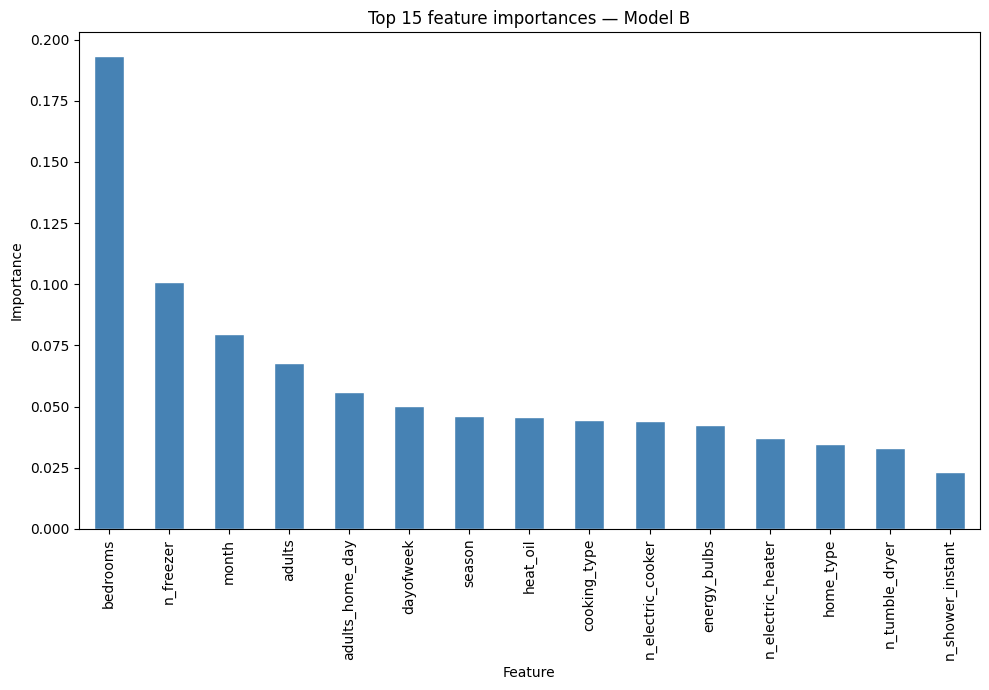

bedrooms             0.193272
n_freezer            0.100979
month                0.079515
adults               0.067909
adults_home_day      0.055888
dayofweek            0.050142
season               0.046091
heat_oil             0.045827
cooking_type         0.044656
n_electric_cooker    0.044079
energy_bulbs         0.042485
n_electric_heater    0.037096
home_type            0.034861
n_tumble_dryer       0.032933
n_shower_instant     0.023368
dtype: float64


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = temporal_features + survey_features
importances = rf_B.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 feature importances — Model B')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp.head(15))

### Key insights

Two Random Forest models were trained to forecast daily household electricity consumption using a chronological train/test split, with the final three months (October–December 2010) reserved for evaluation. Model A used only temporal information (month, day of week, weekend indicator and season), while Model B additionally incorporated 24 household survey variables describing occupancy, dwelling characteristics, appliance ownership, heating systems and energy-efficiency measures.

Model B substantially outperformed the temporal baseline, reducing MAE from **13.6 kWh/day** to **7.7 kWh/day** (44% reduction) and RMSE from **18.1 kWh/day** to **12.2 kWh/day** (33% reduction). This demonstrates that household survey characteristics provide substantial predictive information beyond calendar effects alone.

Feature importance analysis revealed that the **number of bedrooms** was the most influential predictor, suggesting that dwelling size is strongly associated with baseline electricity demand. Occupancy measures (**number of adults** and **adults typically at home during the day**) were also highly important, supporting the hypothesis that household composition is a major driver of energy consumption. Among appliance-related variables, the **number of standalone freezers** was particularly influential, indicating that appliance ownership contributes meaningfully to differences in household demand.

Temporal variables such as **month**, **day of week** and **season** remained important for capturing seasonal and behavioural patterns, but household-level characteristics collectively contributed more predictive information than temporal effects alone. Overall, the results provide strong evidence that integrating survey data significantly improves forecasts of household electricity consumption.

In [24]:
from sklearn.metrics import r2_score

r2_A = r2_score(y_test, preds_A)
r2_B = r2_score(y_test, preds_B)

print(f"Model A R²: {r2_A:.3f}")
print(f"Model B R²: {r2_B:.3f}")

Model A R²: 0.036
Model B R²: 0.562


In [25]:
results = pd.DataFrame({
    'Model': ['Temporal only', 'Temporal + Survey'],
    'MAE': [
        mean_absolute_error(y_test, preds_A),
        mean_absolute_error(y_test, preds_B)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, preds_A)),
        np.sqrt(mean_squared_error(y_test, preds_B))
    ],
    'R²': [
        r2_score(y_test, preds_A),
        r2_score(y_test, preds_B)
    ]
})

print(results)

               Model        MAE       RMSE        R²
0      Temporal only  13.636665  18.118288  0.035602
1  Temporal + Survey   7.691677  12.209195  0.562079


In [26]:
print(results.to_string(index=False, float_format='{:.3f}'.format))

            Model    MAE   RMSE    R²
    Temporal only 13.637 18.118 0.036
Temporal + Survey  7.692 12.209 0.562


### Model comparison

The baseline Random Forest model using only temporal variables performed poorly (R² = 0.036), indicating that calendar effects alone explain little of the variation in household electricity demand. This is consistent with the exploratory analysis, which revealed substantial differences in consumption between households.

Adding 24 survey-derived household characteristics dramatically improved predictive performance. The enhanced model reduced MAE from 13.6 to 7.7 kWh/day (44% reduction), reduced RMSE from 18.1 to 12.2 kWh/day (33% reduction), and increased R² from 0.036 to 0.562.

These results demonstrate that household-level characteristics such as dwelling size, occupancy, appliance ownership, and heating systems contain substantial predictive information beyond temporal effects. In particular, feature importance analysis identified the number of bedrooms, household occupancy, and appliance ownership measures as some of the strongest predictors of electricity demand.

Overall, the analysis provides strong evidence that integrating survey information with smart-meter data significantly improves household electricity demand forecasting.

## Discussion and Further Analysis

The forecasting results demonstrate that household survey information provides substantial predictive value beyond temporal information alone, reducing MAE by 44% and RMSE by 33% relative to the temporal baseline model. However, several limitations should be acknowledged.

First, the Random Forest model treats each household-day as an independent observation and therefore does not explicitly capture temporal dependence within a household's consumption history. Electricity demand is naturally autocorrelated, meaning that recent consumption patterns are likely to influence future demand. Incorporating lagged consumption variables or rolling averages would likely improve predictive performance.

Second, the analysis was performed at the daily level. Daily aggregation simplifies modelling and allows straightforward integration of survey variables, but it removes the rich intra-day patterns visible in the half-hourly data. Future work could develop half-hourly forecasting models capable of capturing the strong morning and evening demand peaks identified during the exploratory analysis.

Third, the survey variables are static and were collected at a single point in time. While they successfully explain differences between households, they do not capture behavioural changes, occupancy fluctuations, weather effects, or changes in appliance usage throughout the study period.

Several extensions could strengthen the analysis. The most immediate improvement would be the inclusion of lagged daily consumption features, as previous electricity usage is typically one of the strongest predictors of future demand. More advanced approaches, such as Gradient Boosting, XGBoost, or Bayesian hierarchical models, could also be explored to better quantify uncertainty and household-level variation. In addition, clustering households according to their consumption profiles may reveal distinct behavioural groups, enabling more targeted forecasting and energy-management strategies.

Overall, the results suggest that household characteristics are at least as important as temporal factors for explaining electricity demand. The substantial improvement achieved by incorporating survey variables indicates that combining behavioural and demographic information with smart-meter data is a promising approach for household energy forecasting.

In [27]:
# Run this in your notebook to see your environment
import pkg_resources

packages = ['pandas', 'numpy', 'matplotlib', 'scikit-learn']
for p in packages:
    version = pkg_resources.get_distribution(p).version
    print(f"{p}=={version}")

pandas==2.3.0
numpy==2.2.5
matplotlib==3.10.1
scikit-learn==1.7.0


C:\Users\sange\AppData\Local\Temp\ipykernel_23840\1697423865.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
